# Model Metrics & Training Diagnostics Visualization

This notebook reads, parses, and visualizes model training logs, metrics, data pre-filtering statistics, and feature importances from `model.json` or `metrics.json` artifacts.

In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Check for available files
model_json_path = 'model.json'
if not os.path.exists(model_json_path) and os.path.exists('test_model.json'):
    model_json_path = 'test_model.json'

print(f"Reading model metadata from: {model_json_path}")
with open(model_json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

summary = data.get('training_summary', data)
print(f"Loaded model artifact trained at: {summary.get('trained_at', data.get('trained_at'))}")
print(f"Model Backend: {data.get('model_backend')}")
print(f"Dataset: {summary.get('training_dataset', data.get('training_dataset'))}")

Reading model metadata from: model.json
Loaded model artifact trained at: 2026-05-23T04:53:38.757414+00:00
Model Backend: lightgbm
Dataset: pushshift_reddit_apr2019


## 1. Training History & Learning Curves

Plot the training and validation loss (RMSE and MAE) over iterations.

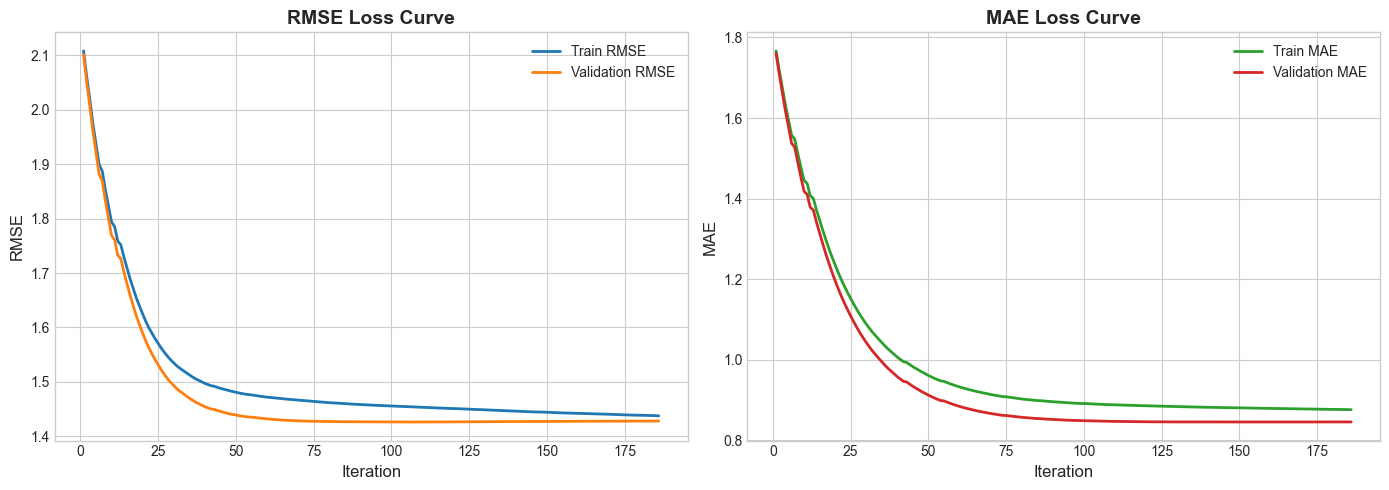

In [2]:
history = summary.get('history', [])
if history:
    iterations = [h['iteration'] for h in history]

    train_rmse = [h.get('train_rmse') for h in history]
    val_rmse = [h.get('validation_rmse') for h in history]

    train_mae = [h.get('train_mae') for h in history]
    val_mae = [h.get('validation_mae') for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot RMSE
    if any(x is not None for x in train_rmse):
        axes[0].plot(iterations, train_rmse, label='Train RMSE', color='#1f77b4', linewidth=2)
    if any(x is not None for x in val_rmse):
        axes[0].plot(iterations, val_rmse, label='Validation RMSE', color='#ff7f0e', linewidth=2)
    axes[0].set_title('RMSE Loss Curve', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('RMSE', fontsize=12)
    axes[0].legend(fontsize=10)

    # Plot MAE
    if any(x is not None for x in train_mae):
        axes[1].plot(iterations, train_mae, label='Train MAE', color='#2ca02c', linewidth=2)
    if any(x is not None for x in val_mae):
        axes[1].plot(iterations, val_mae, label='Validation MAE', color='#d62728', linewidth=2)
    axes[1].set_title('MAE Loss Curve', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Iteration', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].legend(fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No training history found.")

## 2. Feature Importances

Visualize the features that contribute the most value to the model predictions.

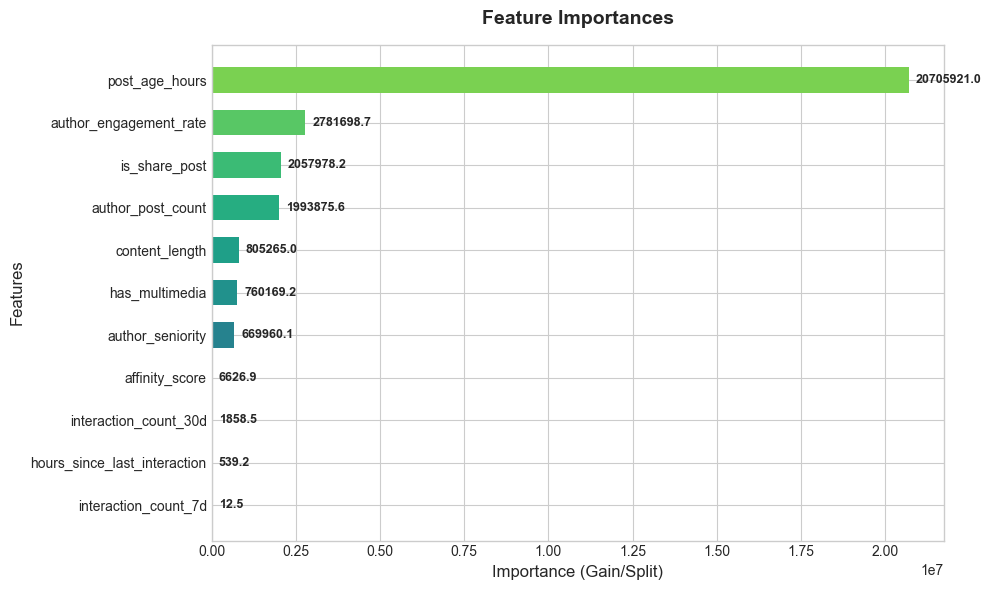

In [3]:
importances = summary.get('feature_importances', {})
if importances:
    sorted_features = sorted(importances.items(), key=lambda x: x[1], reverse=True)
    names = [x[0] for x in sorted_features]
    values = [x[1] for x in sorted_features]

    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(names)))
    bars = plt.barh(names[::-1], values[::-1], color=colors[::-1], height=0.6)

    plt.title('Feature Importances', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Importance (Gain/Split)', fontsize=12)
    plt.ylabel('Features', fontsize=12)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}',
                 va='center', ha='left', fontsize=9, fontweight='semibold')

    plt.tight_layout()
    plt.show()
else:
    print("No feature importances found.")

## 3. Data Filtering Statistics

Visualize the reasons why candidate posts were filtered out during the ingestion process.

Submissions Scanned: 18,310,157
Submissions Filtered: 8,445,428 (46.1%)
Submissions Accepted: 9,864,729 (53.9%)


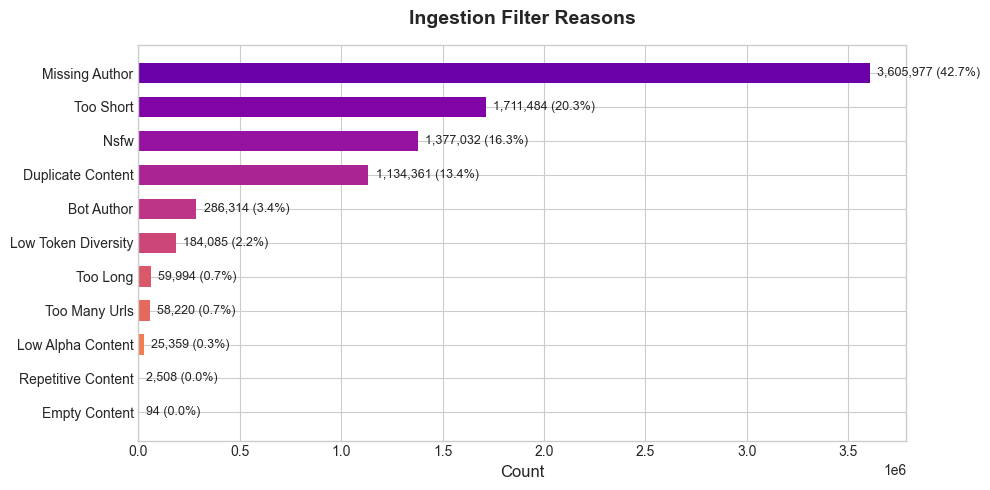

In [4]:
scan_stats = summary.get('scan_stats', {})
if scan_stats:
    scanned = scan_stats.get('submissions_scanned', 0)
    filtered = scan_stats.get('submissions_filtered', 0)
    accepted = scan_stats.get('submissions_accepted', 0)

    print(f"Submissions Scanned: {scanned:,}")
    print(f"Submissions Filtered: {filtered:,} ({filtered/scanned*100:.1f}%)")
    print(f"Submissions Accepted: {accepted:,} ({accepted/scanned*100:.1f}%)")

    reasons = scan_stats.get('filter_reasons', {})
    if reasons:
        sorted_reasons = sorted(reasons.items(), key=lambda x: x[1], reverse=True)
        r_names = [x[0].replace('_', ' ').title() for x in sorted_reasons]
        r_values = [x[1] for x in sorted_reasons]

        plt.figure(figsize=(10, 5))
        colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(r_names)))
        bars = plt.barh(r_names[::-1], r_values[::-1], color=colors[::-1], height=0.6)

        plt.title('Ingestion Filter Reasons', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Count', fontsize=12)

        total_filtered = sum(r_values)
        for bar in bars:
            width = bar.get_width()
            pct = (width / total_filtered * 100) if total_filtered > 0 else 0
            plt.text(width + max(r_values)*0.01, bar.get_y() + bar.get_height()/2,
                     f'{width:,} ({pct:.1f}%)',
                     va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.show()
else:
    print("No scan stats found.")

## 4. Interaction Skipped Statistics

Analyze why user interactions/comments were excluded from calculations.

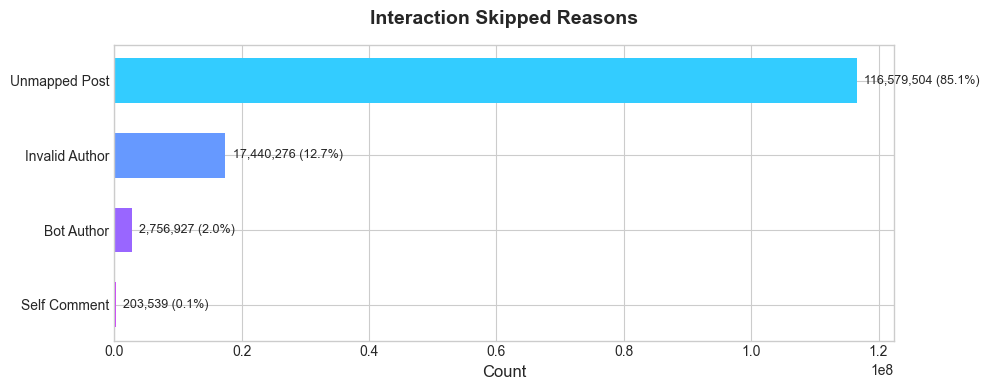

In [5]:
interaction_stats = summary.get('interaction_stats', {})
if interaction_stats:
    reasons = interaction_stats.get('skipped_reasons', {})
    if reasons:
        sorted_reasons = sorted(reasons.items(), key=lambda x: x[1], reverse=True)
        i_names = [x[0].replace('_', ' ').title() for x in sorted_reasons]
        i_values = [x[1] for x in sorted_reasons]

        plt.figure(figsize=(10, 4))
        colors = plt.cm.cool(np.linspace(0.2, 0.8, len(i_names)))
        bars = plt.barh(i_names[::-1], i_values[::-1], color=colors[::-1], height=0.6)

        plt.title('Interaction Skipped Reasons', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Count', fontsize=12)

        total_skipped = sum(i_values)
        for bar in bars:
            width = bar.get_width()
            pct = (width / total_skipped * 100) if total_skipped > 0 else 0
            plt.text(width + max(i_values)*0.01, bar.get_y() + bar.get_height()/2,
                     f'{width:,} ({pct:.1f}%)',
                     va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.show()
else:
    print("No interaction stats found.")

## 5. Model Evaluation Metrics Comparison

Compare metric groups across Train, Validation, and Test datasets.

Metric     | Train      | Validation | Test      
--------------------------------------------------
RMSE       | 1.4545     | 1.4264     | 1.3899    
MAE        | 0.8892     | 0.8475     | 0.8253    
NDCG@K     | 0.9394     | 0.9505     | 0.9574    
R2         | 0.5467     | 0.5627     | 0.5712    
--------------------------------------------------


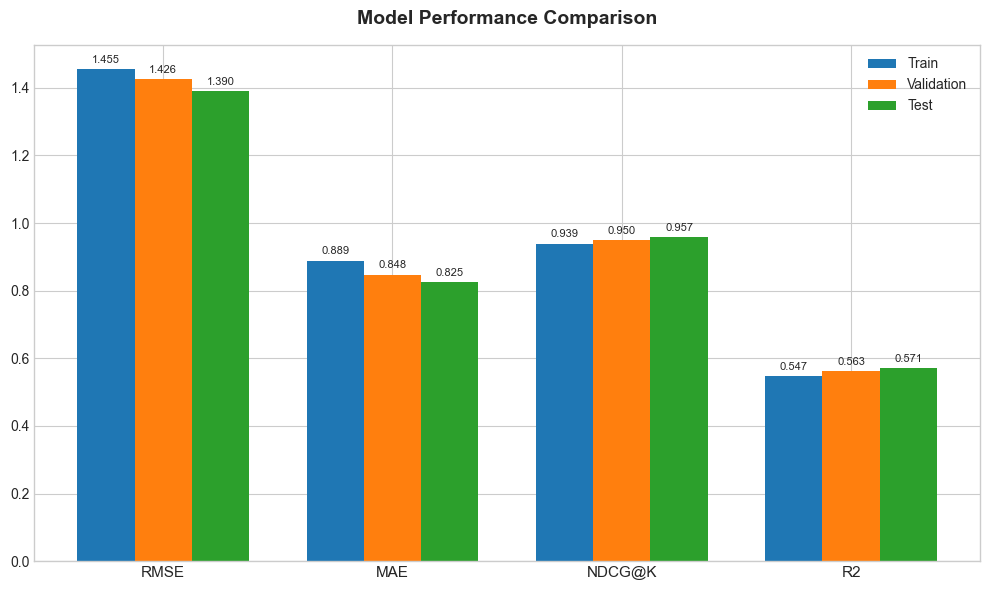

In [6]:
metrics = summary.get('metrics', {})
if metrics:
    metric_groups = {
        'RMSE': (metrics.get('train_rmse'), metrics.get('validation_rmse'), metrics.get('test_rmse')),
        'MAE': (metrics.get('train_mae'), metrics.get('validation_mae'), metrics.get('test_mae')),
        'NDCG@K': (metrics.get('train_ndcg_k'), metrics.get('validation_ndcg_k'), metrics.get('test_ndcg_k')),
        'R2': (metrics.get('train_r2'), metrics.get('validation_r2'), metrics.get('test_r2'))
    }

    print(f"{'Metric':<10} | {'Train':<10} | {'Validation':<10} | {'Test':<10}")
    print("-" * 50)
    for name, vals in metric_groups.items():
        t_val = f"{vals[0]:.4f}" if vals[0] is not None else "N/A"
        v_val = f"{vals[1]:.4f}" if vals[1] is not None else "N/A"
        te_val = f"{vals[2]:.4f}" if vals[2] is not None else "N/A"
        print(f"{name:<10} | {t_val:<10} | {v_val:<10} | {te_val:<10}")
    print("-" * 50)

    labels = list(metric_groups.keys())
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    train_vals = [metric_groups[l][0] or 0.0 for l in labels]
    val_vals = [metric_groups[l][1] or 0.0 for l in labels]
    test_vals = [metric_groups[l][2] or 0.0 for l in labels]

    rects1 = ax.bar(x - width, train_vals, width, label='Train', color='#1f77b4')
    rects2 = ax.bar(x, val_vals, width, label='Validation', color='#ff7f0e')
    rects3 = ax.bar(x + width, test_vals, width, label='Test', color='#2ca02c')

    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend(fontsize=10)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0.0:
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    plt.show()
else:
    print("No metrics found.")